# Bayesian Neural Networks

## Instalación

In [ ]:
#%pip install tensorflow
#%pip install tensorflow-probability
#%pip install tf-keras

In [11]:
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import tf_keras
import matplotlib.pyplot as plt

In [12]:
tfd = tfp.distributions
tfpl = tfp.layers

In [13]:
# --- 1. Generación de Datos Sintéticos ---
# Creamos una función no lineal con algo de ruido
def generate_data(n=150):
    X = np.linspace(-10, 10, n).reshape(-1, 1)
    y = np.sin(X) + 0.1 * X + np.random.normal(0, 0.2, (n, 1))
    return X, y

X_train, y_train = generate_data()

In [14]:
# --- 2. Definición de la Función de Costo (Negative Log Likelihood) ---
def neg_log_likelihood(y_true, y_pred):
    # y_pred es una distribución, no un número
    return -y_pred.log_prob(y_true)

In [17]:
# --- 3. Construcción del Modelo BNN ---
# El término de divergencia KL se añade automáticamente a la pérdida en las capas Flipout
kl_divergence_function = (lambda q, p, _: tfp.distributions.kl_divergence(q, p) /  tf.cast(len(X_train), dtype=tf.float32))

model = tf_keras.Sequential([
    # Capa de entrada
    tf_keras.layers.Input(shape=(1,)),
    
    # Capa Oculta Bayesiana (DenseFlipout reemplaza a Dense)
    # kernel_divergence_fn añade la penalización KL para regularizar la incertidumbre
    tfpl.DenseFlipout(
        20, 
        activation='relu',
        kernel_divergence_fn=kl_divergence_function
    ),
    
    tfpl.DenseFlipout(
        20, 
        activation='relu',
        kernel_divergence_fn=kl_divergence_function
    ),
    
    # Capa de Salida Probabilística
    # No sale un valor, sale una distribución Normal (media y desviación estándar)
    tfpl.DenseFlipout(2, kernel_divergence_fn=kl_divergence_function),
    tfpl.DistributionLambda(lambda t: tfd.Normal(loc=t[..., :1], scale=1e-3 + tf.math.softplus(0.05 * t[..., 1:])))
])

C:\Users\Erick\AppData\Roaming\Python\Python312\site-packages\tensorflow_probability\python\layers\util.py:99: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
C:\Users\Erick\AppData\Roaming\Python\Python312\site-packages\tensorflow_probability\python\layers\util.py:109: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(
C:\Users\Erick\AppData\Roaming\Python\Python312\site-packages\tf_keras\src\initializers\initializers.py:121: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


In [19]:
# --- 4. Compilación y Entrenamiento ---
model.compile(optimizer=tf_keras.optimizers.Adam(learning_rate=0.01), 
              loss=neg_log_likelihood)

print("Entrenando el modelo...")
history = model.fit(X_train, y_train, epochs=500, verbose=0)
print("Entrenamiento finalizado.")

Entrenando el modelo...

Entrenamiento finalizado.


In [20]:
# --- 5. Inferencia (Monte Carlo Sampling) ---
# En una BNN, cada vez que predices, obtienes un resultado ligeramente distinto
# porque los pesos se muestrean de sus distribuciones.
X_test = np.linspace(-15, 15, 300).reshape(-1, 1)

# Realizamos 100 predicciones para ver la dispersión (incertidumbre)
predictions = []
for _ in range(100):
    predictions.append(model.predict(X_test, verbose=0))

predictions = np.array(predictions) # Shape: (100, 300, 1)
mean_pred = predictions.mean(axis=0).flatten()
std_pred = predictions.std(axis=0).flatten()

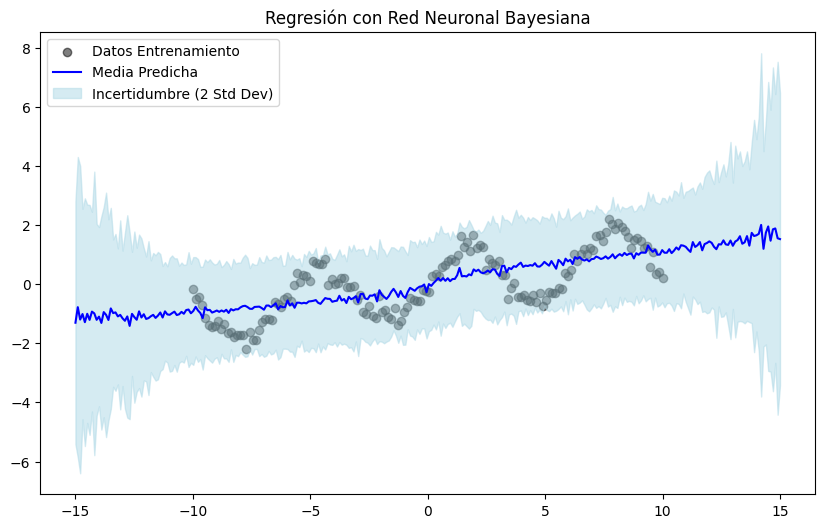

In [21]:
# --- 6. Visualización ---
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='black', label='Datos Entrenamiento', alpha=0.5)
plt.plot(X_test, mean_pred, color='blue', label='Media Predicha')
plt.fill_between(X_test.flatten(), 
                 mean_pred - 2*std_pred, 
                 mean_pred + 2*std_pred, 
                 color='lightblue', alpha=0.5, label='Incertidumbre (2 Std Dev)')
plt.title('Regresión con Red Neuronal Bayesiana')
plt.legend()
plt.show()